# Financial News Sentiment Analysis — Results & Analysis

This notebook loads all persisted results and generates figures/tables for the report.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

# Load evaluation results
eval_results = json.loads(Path("../results/metrics/evaluation_results.json").read_text())
data_stats = json.loads(Path("../results/metrics/data_stats.json").read_text())
market_trend = json.loads(Path("../results/metrics/market_trend.json").read_text())

per_window = pd.DataFrame(eval_results["per_window"])
aggregated = pd.DataFrame(eval_results["aggregated"])

print("Data Stats:")
print(json.dumps(data_stats, indent=2))

Data Stats:
{
  "total_article_ticker_pairs": 20550,
  "unique_articles": 20550,
  "unique_tickers": 381,
  "date_range": [
    "2017-01-03",
    "2020-12-30"
  ],
  "horizons": [
    1,
    3,
    5,
    10,
    30
  ],
  "horizon_availability": {
    "r_1d": 20550,
    "r_3d": 20550,
    "r_5d": 20550,
    "r_10d": 20550,
    "r_30d": 20550
  },
  "windows": {
    "split": {
      "train": 10320,
      "val": 5338,
      "test": 4892
    }
  }
}


## 1. Data Description

In [2]:
# Dataset overview
print(f"Total article-ticker pairs: {data_stats['total_article_ticker_pairs']}")
print(f"Unique articles: {data_stats['unique_articles']}")
print(f"Unique tickers: {data_stats['unique_tickers']}")
print(f"Date range: {data_stats['date_range']}")

# Window sizes
window_df = pd.DataFrame(data_stats["windows"]).T
display(window_df)

# Horizon availability
horizon_df = pd.DataFrame([data_stats["horizon_availability"]])
display(horizon_df)

Total article-ticker pairs: 20550
Unique articles: 20550
Unique tickers: 381
Date range: ['2017-01-03', '2020-12-30']


,train,val,test
split,10320,5338,4892


,r_1d,r_3d,r_5d,r_10d,r_30d
0,20550,20550,20550,20550,20550


## 2. Fine-Tuned Model Evaluation: R² and MSE

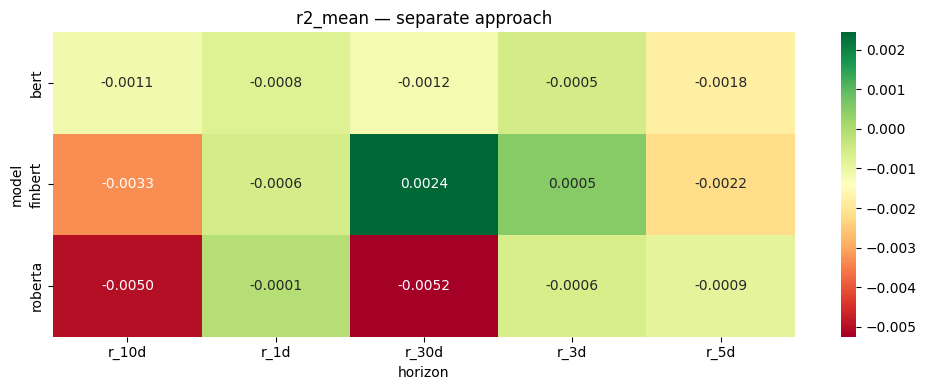

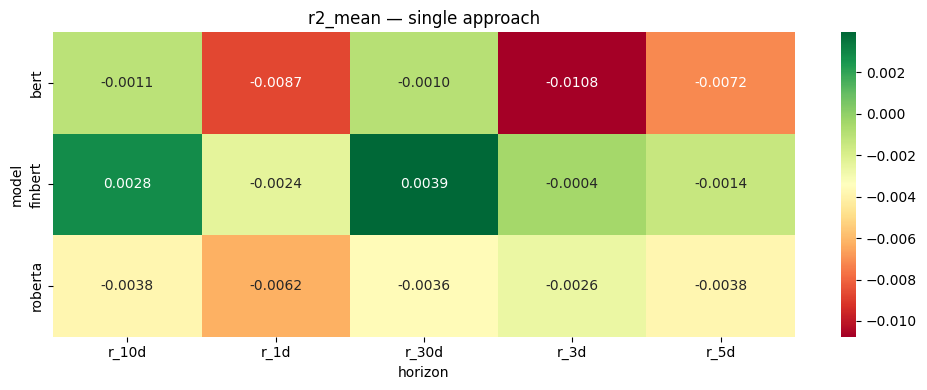

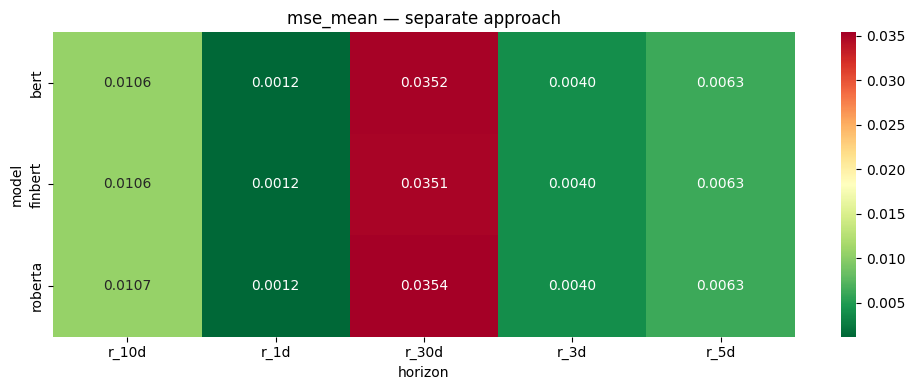

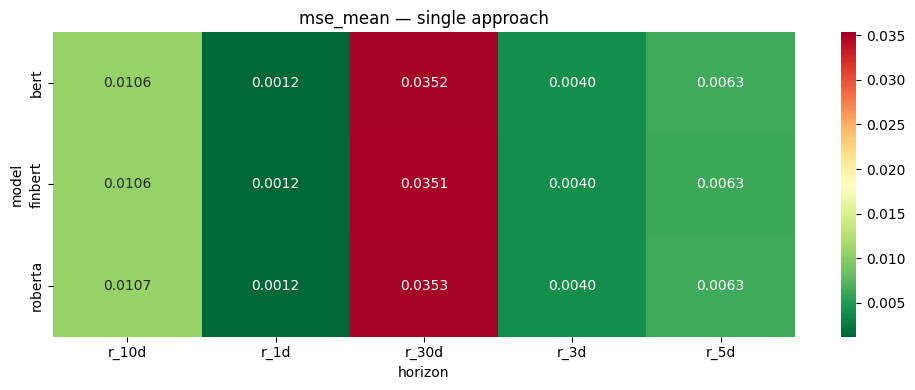

In [3]:
ft = aggregated[aggregated["model_type"] == "finetuned"].copy()

for metric in ["r2_mean", "mse_mean"]:
    for approach in ["separate", "single"]:
        subset = ft[ft["approach"] == approach]
        if subset.empty:
            continue
        pivot = subset.pivot(index="model", columns="horizon", values=metric)
        fig, ax = plt.subplots(figsize=(10, 4))
        sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdYlGn" if "r2" in metric else "RdYlGn_r", ax=ax)
        ax.set_title(f"{metric} — {approach} approach")
        fig.tight_layout()
        fig.savefig(f"../results/figures/heatmap_{metric}_{approach}.png", dpi=150)
        plt.show()

## 3. Training Loss Curves

In [8]:
import glob

log_files = sorted(glob.glob("../results/training_logs/*_log.json"))

# Plot one example per encoder (best config, r_1d, window_1)
for encoder in ["bert", "finbert", "roberta"]:
    log_path = f"../results/training_logs/{encoder}_separate_1d_window_1_log.json"
    if not Path(log_path).exists():
        continue
    log = json.loads(Path(log_path).read_text())
    logs = pd.DataFrame(log["logs"])

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(logs["epoch"], logs["train_loss"], label="Train")
    ax.plot(logs["epoch"], logs["val_loss"], label="Validation")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MSE Loss")
    ax.set_title(f"{encoder} — r_1d — Window 1")
    ax.legend()
    fig.tight_layout()
    fig.savefig(f"../results/figures/loss_curve_{encoder}_1d_w1.png", dpi=150)
    plt.show()

## 4. Binary Prediction: Accuracy & F1

,model,model_type,approach,horizon,fixed_accuracy_mean,fixed_f1_mean,learned_accuracy_mean,learned_f1_mean
0,bert,finetuned,separate,r_10d,0.5636,0.3604,0.5253,0.5135
1,bert,finetuned,separate,r_1d,0.5088,0.3387,0.5070,0.3447
2,bert,finetuned,separate,r_30d,0.6022,0.3773,0.5601,0.4945
3,bert,finetuned,separate,r_3d,0.5194,0.3453,0.5106,0.4920
4,bert,finetuned,separate,r_5d,0.5390,0.3542,0.5061,0.4896
5,bert,finetuned,single,r_10d,0.5642,0.3607,0.5215,0.5029
6,bert,finetuned,single,r_1d,0.4951,0.3419,0.5063,0.4392
7,bert,finetuned,single,r_30d,0.6036,0.3764,0.5331,0.4888
8,bert,finetuned,single,r_3d,0.4822,0.3425,0.5121,0.4499
9,bert,finetuned,single,r_5d,0.5286,0.4894,0.5268,0.4945


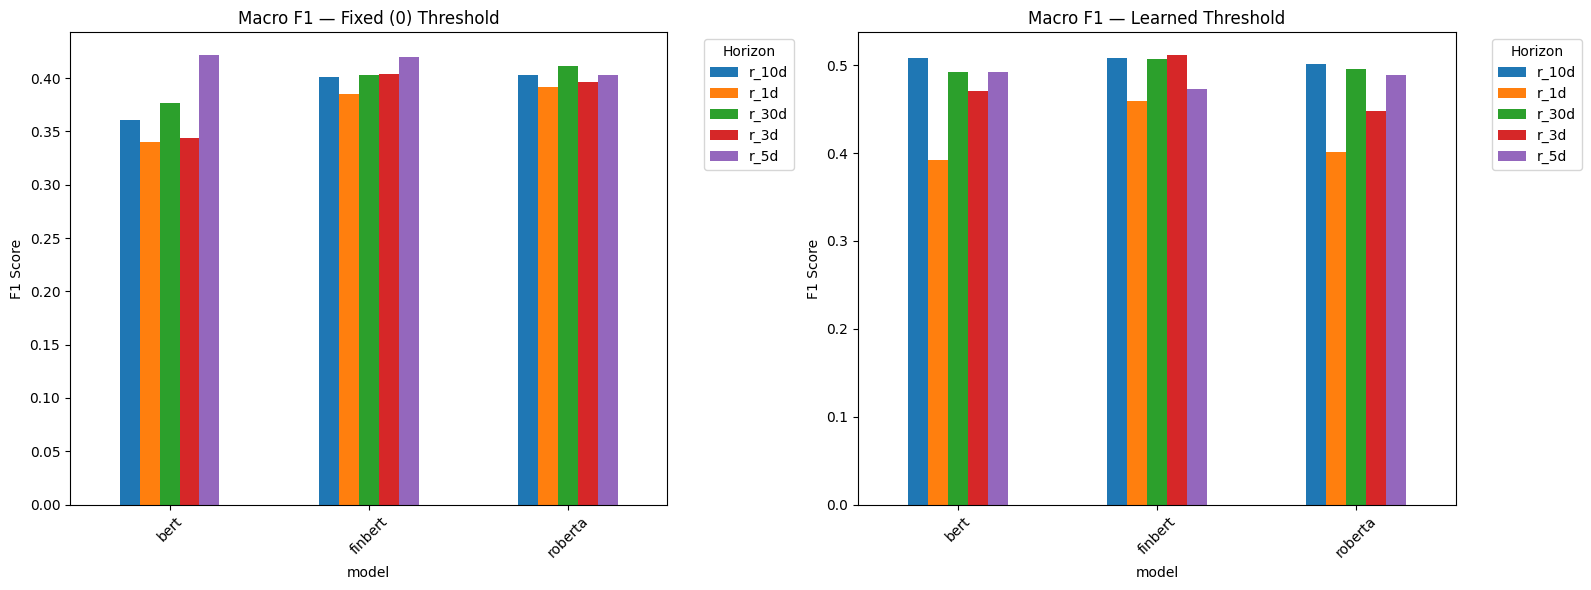

In [9]:
# Compare fixed vs learned threshold
binary_cols = ["model", "model_type", "approach", "horizon",
               "fixed_accuracy_mean", "fixed_f1_mean",
               "learned_accuracy_mean", "learned_f1_mean"]
binary_df = aggregated[[c for c in binary_cols if c in aggregated.columns]].copy()
display(binary_df.round(4))

# Bar chart: F1 by model and horizon
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, (threshold_type, col) in zip(axes, [("Fixed (0)", "fixed_f1_mean"), ("Learned", "learned_f1_mean")]):
    if col not in aggregated.columns:
        continue
    pivot = aggregated.pivot_table(index="model", columns="horizon", values=col, aggfunc="mean")
    pivot.plot(kind="bar", ax=ax)
    ax.set_title(f"Macro F1 — {threshold_type} Threshold")
    ax.set_ylabel("F1 Score")
    ax.legend(title="Horizon", bbox_to_anchor=(1.05, 1))
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
fig.tight_layout()
fig.savefig("../results/figures/binary_f1_comparison.png", dpi=150)
plt.show()

## 5. Separate vs Single Model Comparison

mse_mean          r2_mean        
approach        separate  single separate  single
model   horizon                                  
bert    r_10d     0.0106  0.0106  -0.0011 -0.0011
        r_1d      0.0012  0.0012  -0.0008 -0.0087
        r_30d     0.0352  0.0352  -0.0012 -0.0010
        r_3d      0.0040  0.0040  -0.0005 -0.0108
        r_5d      0.0063  0.0063  -0.0018 -0.0072
finbert r_10d     0.0106  0.0106  -0.0033  0.0028
        r_1d      0.0012  0.0012  -0.0006 -0.0024
        r_30d     0.0351  0.0351   0.0024  0.0039
        r_3d      0.0040  0.0040   0.0005 -0.0004
        r_5d      0.0063  0.0063  -0.0022 -0.0014
roberta r_10d     0.0107  0.0107  -0.0050 -0.0038
        r_1d      0.0012  0.0012  -0.0001 -0.0062
        r_30d     0.0354  0.0353  -0.0052 -0.0036
        r_3d      0.0040  0.0040  -0.0006 -0.0026
        r_5d      0.0063  0.0063  -0.0009 -0.0038

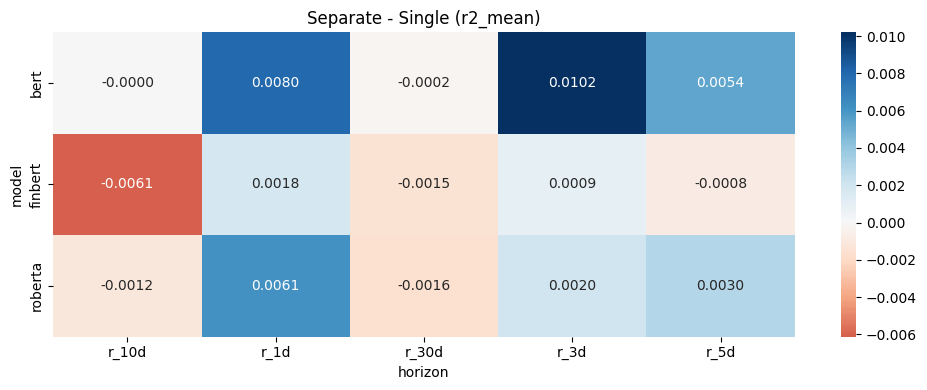

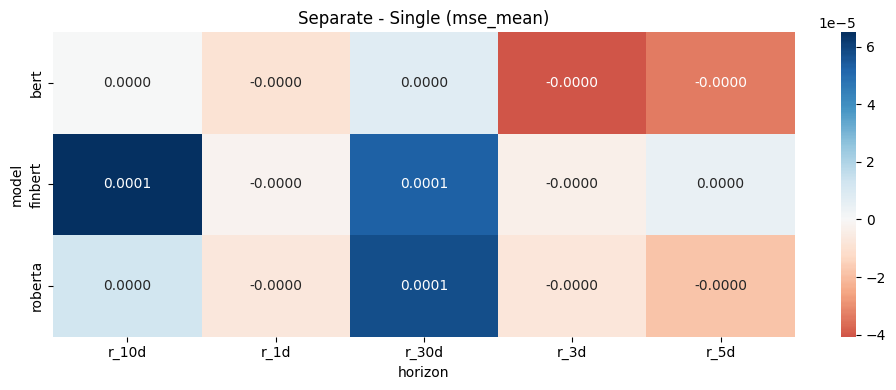

In [10]:
ft_only = aggregated[aggregated["model_type"] == "finetuned"]
comparison = ft_only.pivot_table(
    index=["model", "horizon"],
    columns="approach",
    values=["r2_mean", "mse_mean"],
    aggfunc="mean"
)
display(comparison.round(4))

# Difference plot
for metric in ["r2_mean", "mse_mean"]:
    if metric not in ft_only.columns:
        continue
    sep = ft_only[ft_only["approach"] == "separate"].set_index(["model", "horizon"])[metric]
    sin = ft_only[ft_only["approach"] == "single"].set_index(["model", "horizon"])[metric]
    diff = (sep - sin).reset_index()
    diff.columns = ["model", "horizon", "difference"]
    pivot = diff.pivot(index="model", columns="horizon", values="difference")
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(pivot, annot=True, fmt=".4f", center=0, cmap="RdBu", ax=ax)
    ax.set_title(f"Separate - Single ({metric})")
    fig.tight_layout()
    fig.savefig(f"../results/figures/approach_diff_{metric}.png", dpi=150)
    plt.show()

## 6. Sentiment & Market Trend Analysis

,label,n_months,ols_beta,ols_alpha,ols_r2,ols_p_value,pearson_r,pearson_p,spearman_r,spearman_p
0,Pretrained finbert,46,-0.1191,-0.0226,0.0401,0.1824,-0.2001,0.1824,-0.2021,0.1780
1,Pretrained roberta,46,-0.1453,0.0145,0.0234,0.3100,-0.1530,0.3100,-0.1683,0.2635
2,"Finetuned bert (separate, r_30d)",11,0.2923,-0.0155,0.0053,0.8323,0.0725,0.8323,-0.0455,0.8944
3,"Finetuned bert (single, r_30d)",11,0.0010,0.0163,0.0000,0.9983,0.0007,0.9983,-0.0909,0.7904
4,"Finetuned finbert (separate, r_30d)",11,1.3508,-0.3266,0.3764,0.0447,0.6135,0.0447,0.6545,0.0289
5,"Finetuned finbert (single, r_30d)",11,0.9094,-0.2234,0.3129,0.0736,0.5594,0.0736,0.5818,0.0604
6,"Finetuned roberta (separate, r_30d)",11,0.9022,0.0872,0.1879,0.1830,0.4334,0.1830,0.4818,0.1334
7,"Finetuned roberta (single, r_30d)",11,0.0061,0.0181,0.0000,0.9945,0.0024,0.9945,0.0636,0.8525



scatter_finetuned_bert_(separate,_r_30d)


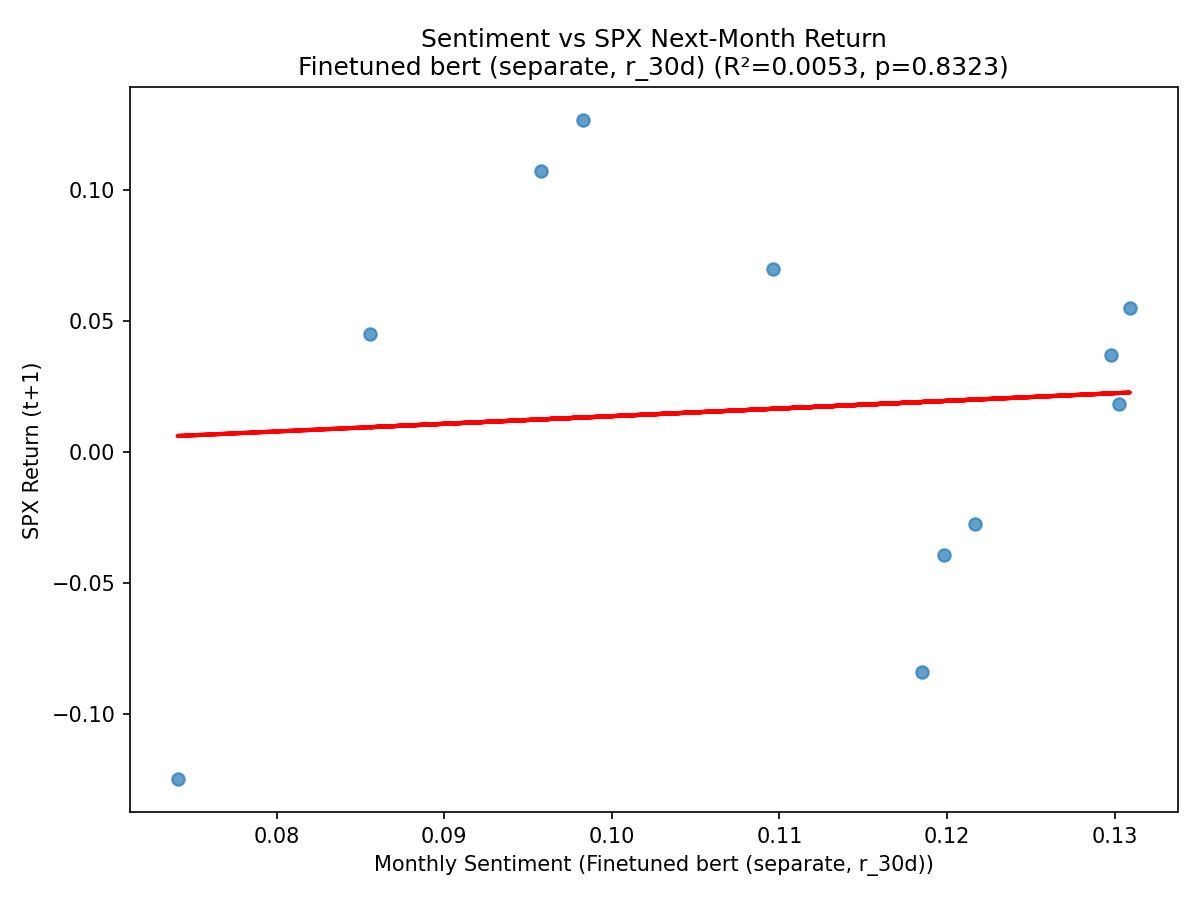


scatter_finetuned_bert_(single,_r_30d)


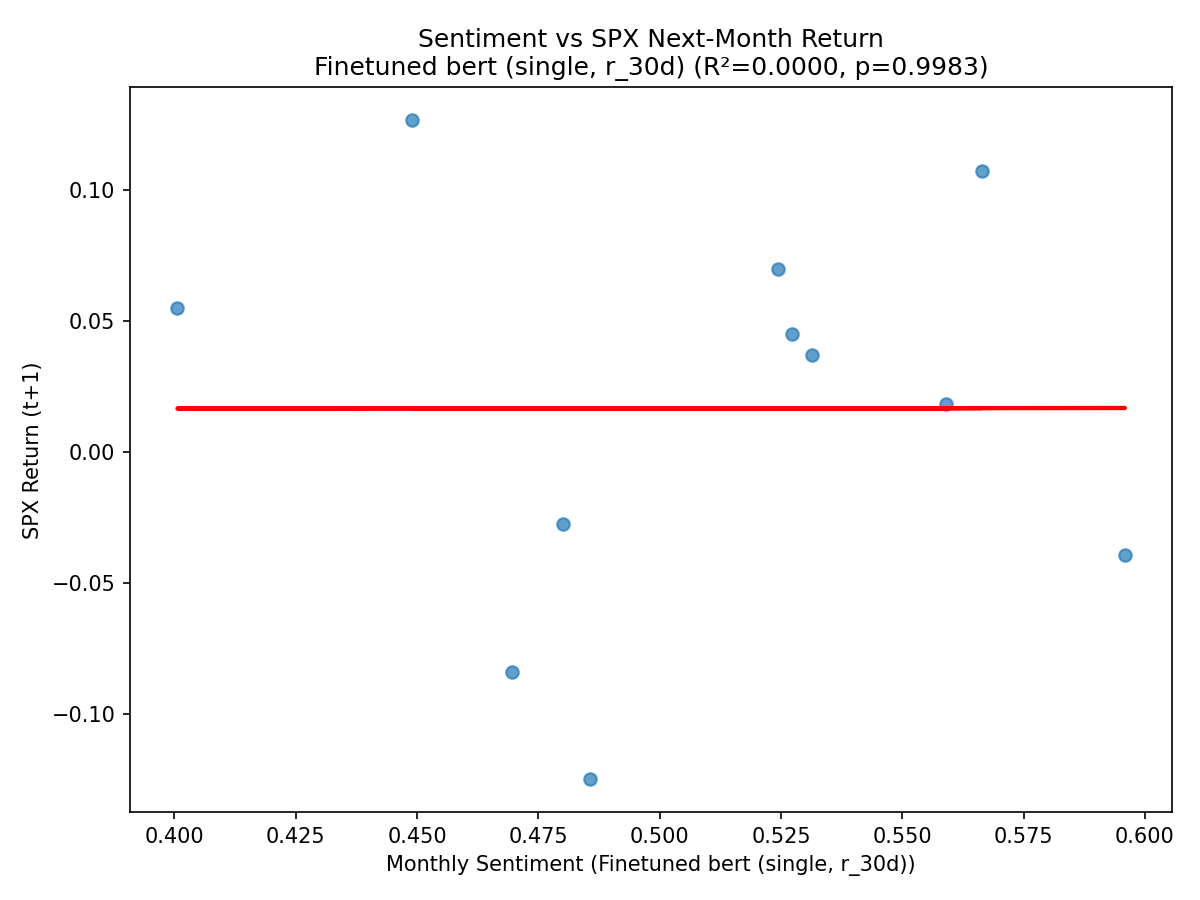


scatter_finetuned_finbert_(separate,_r_30d)


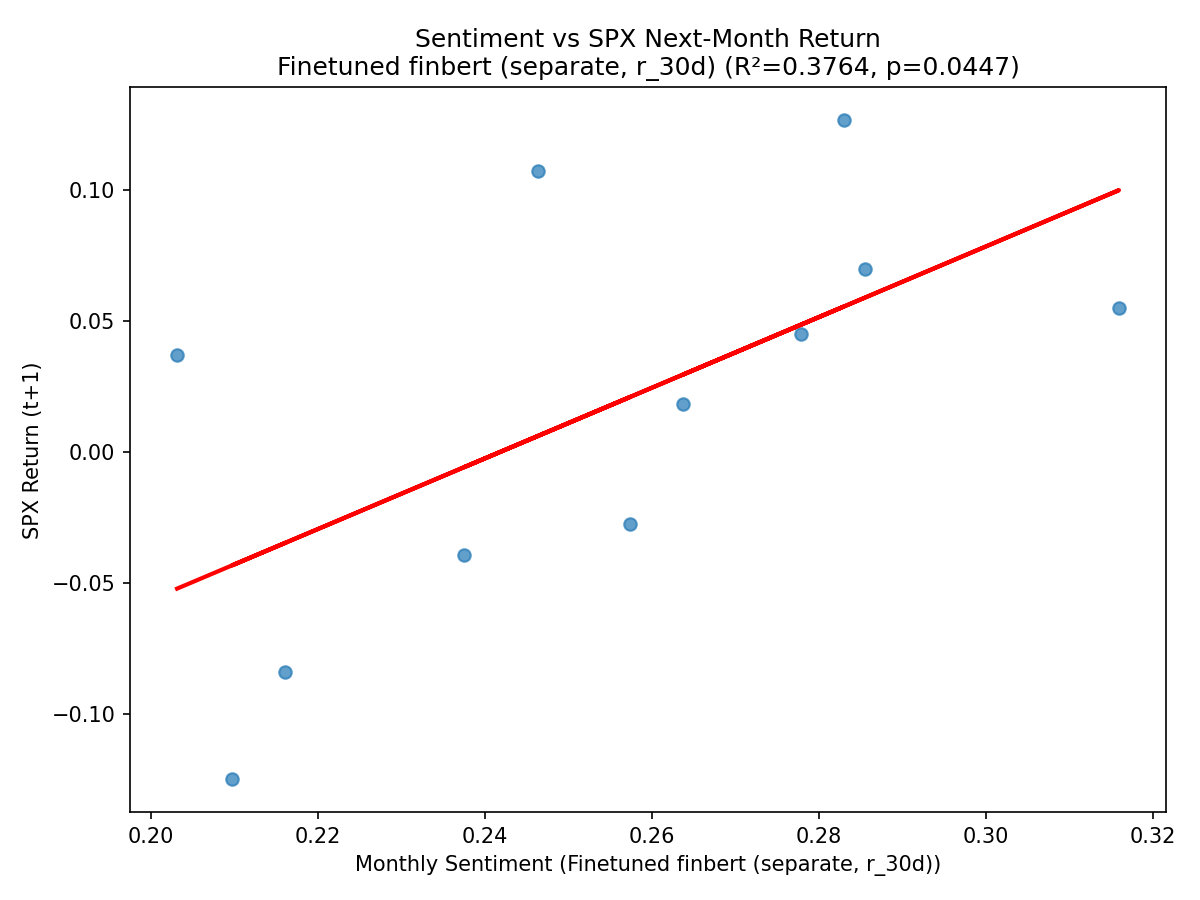


scatter_finetuned_finbert_(single,_r_30d)


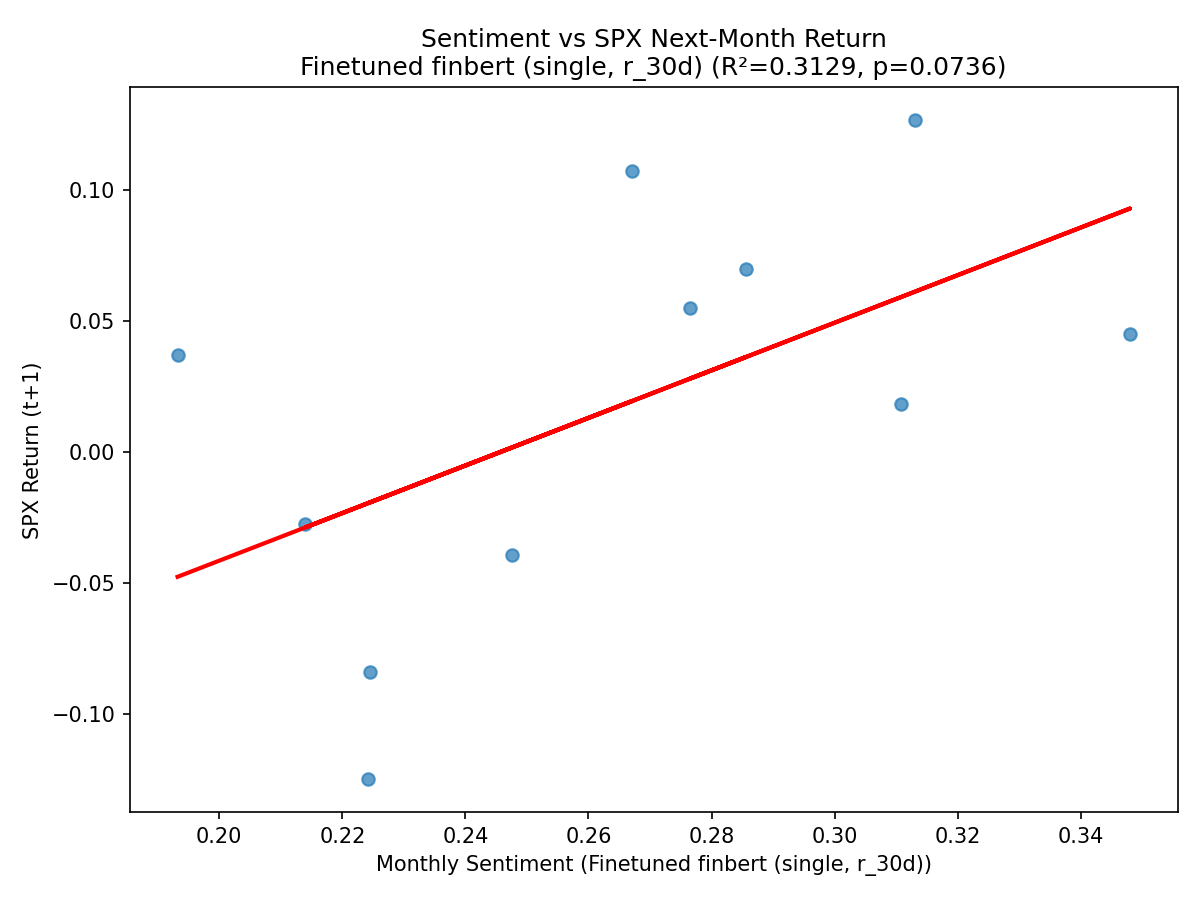


scatter_finetuned_roberta_(separate,_r_30d)


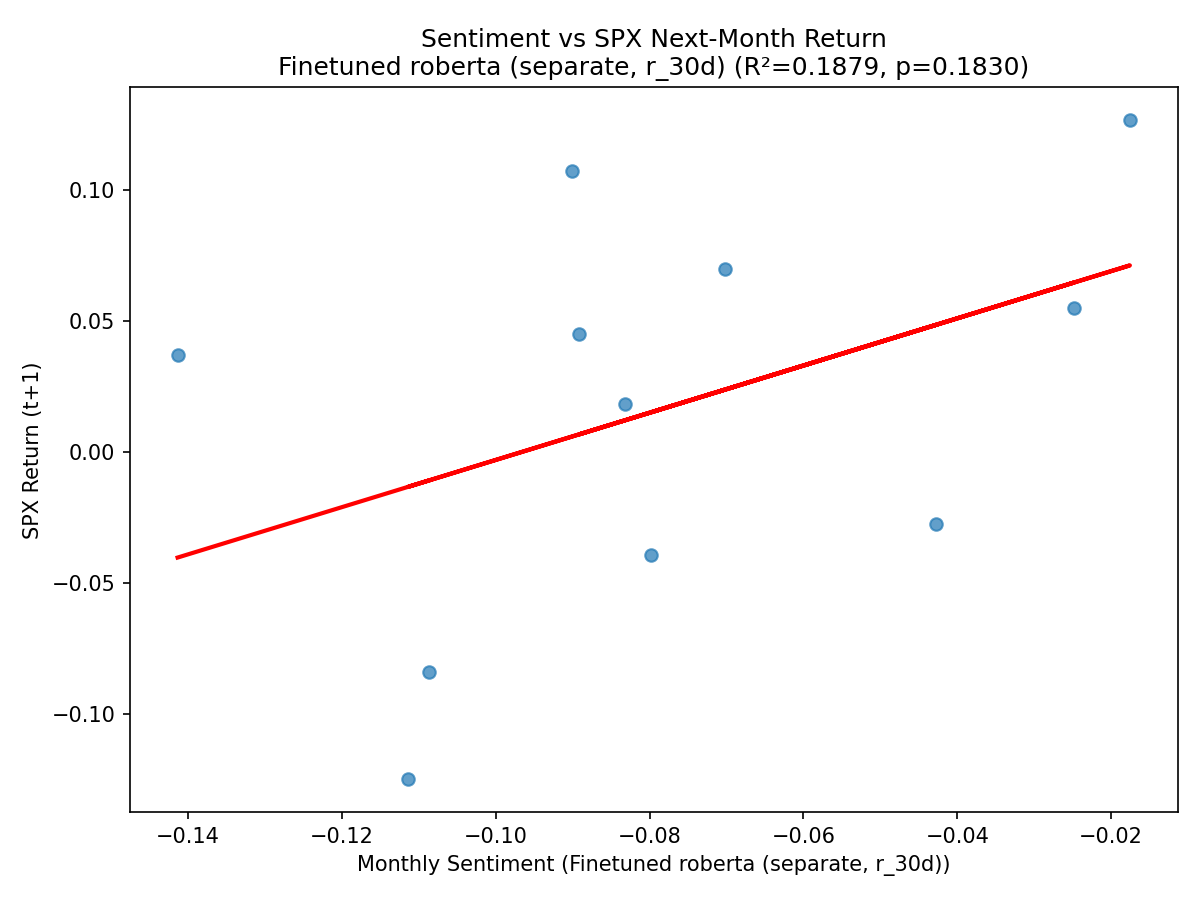


scatter_finetuned_roberta_(single,_r_30d)


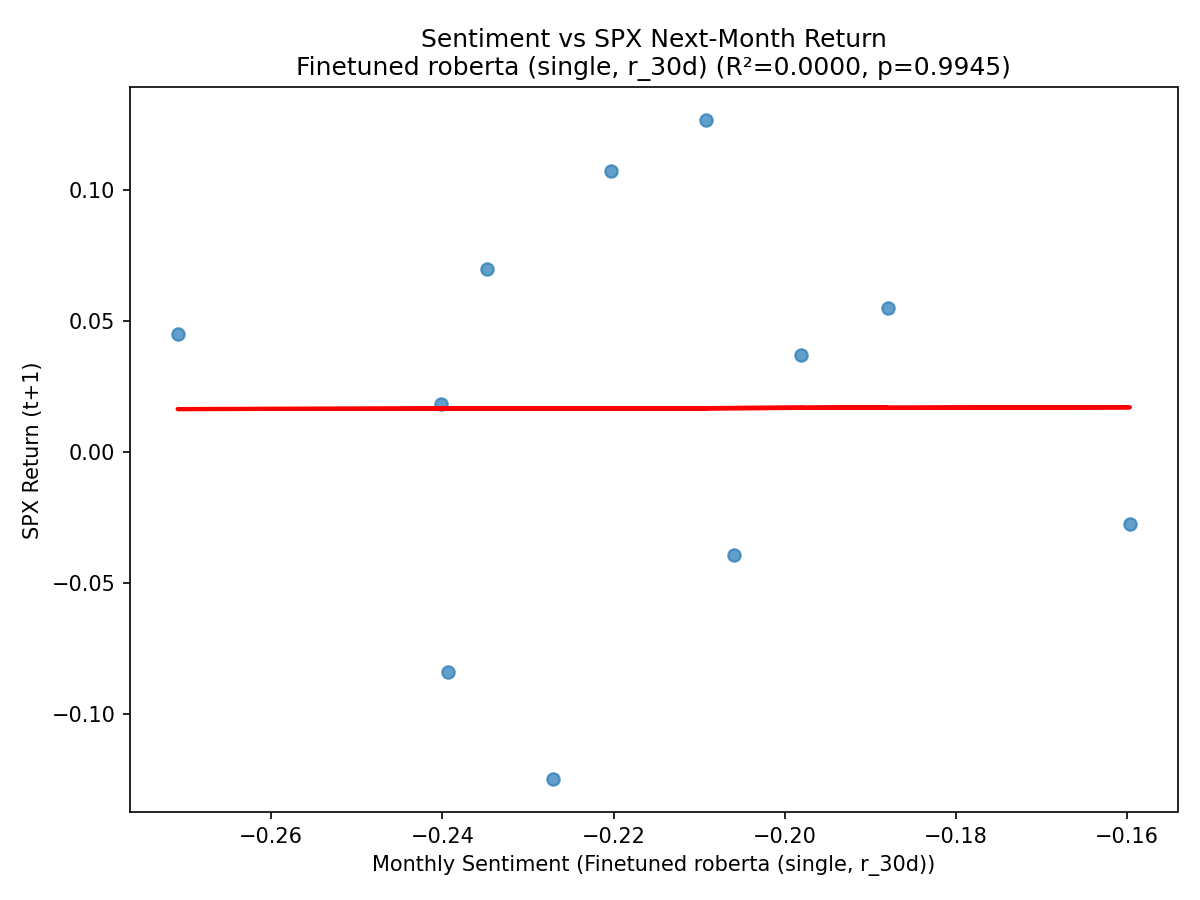


scatter_pretrained_finbert


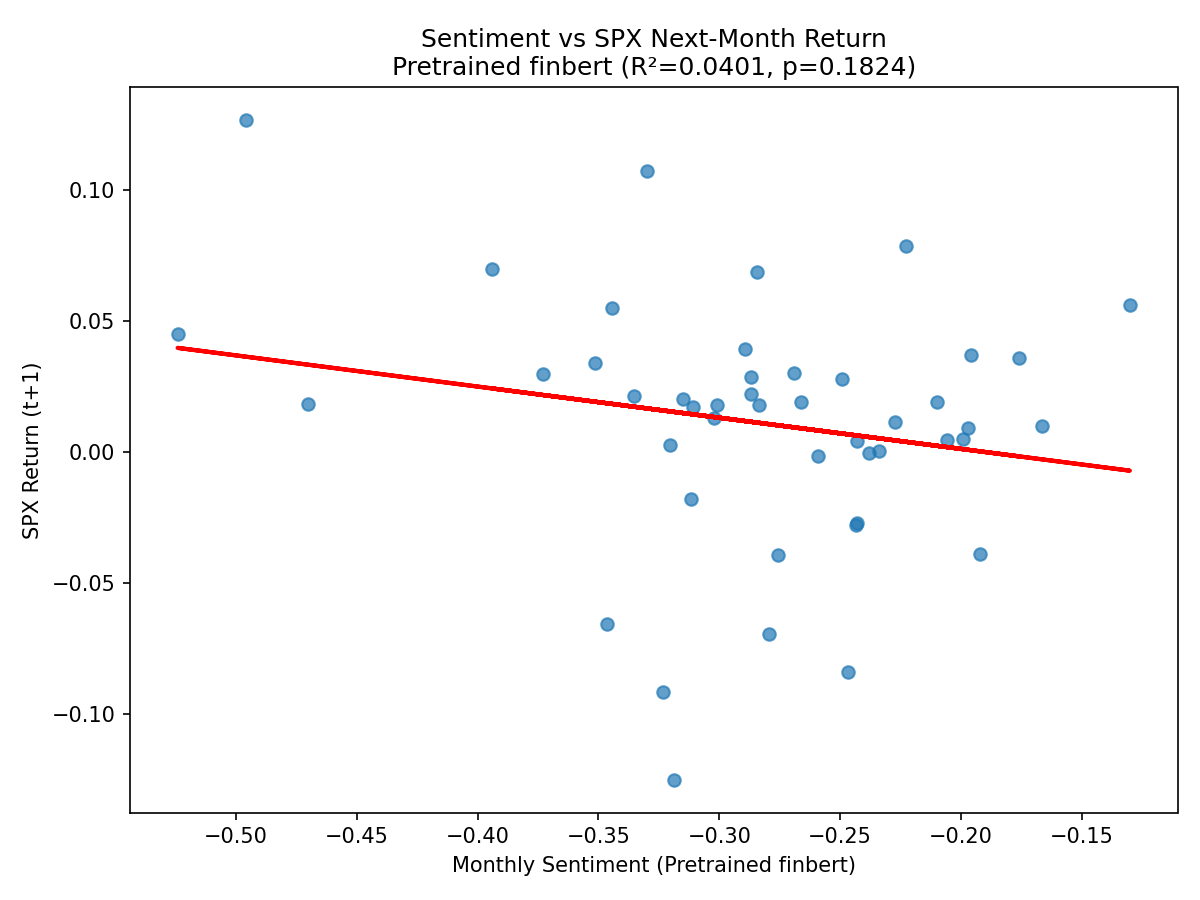


scatter_pretrained_roberta


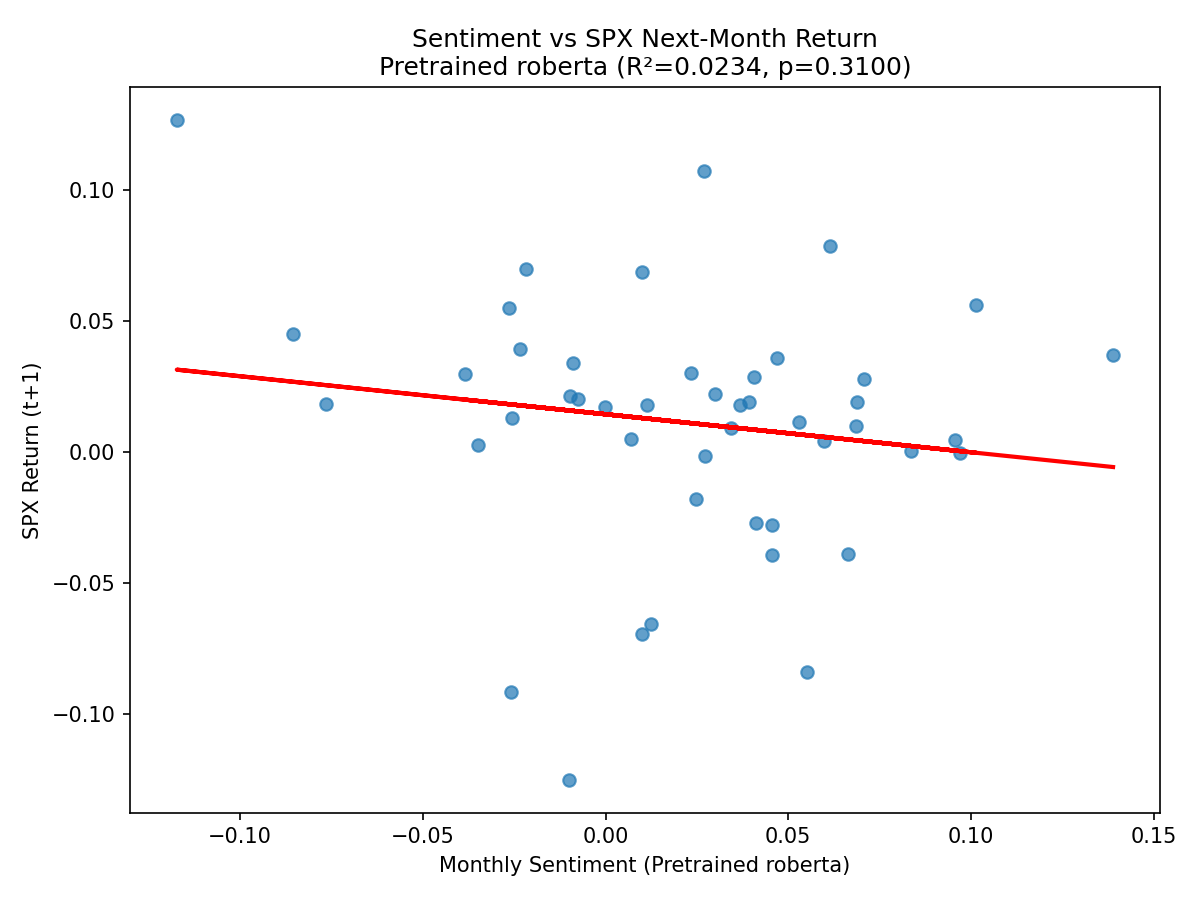

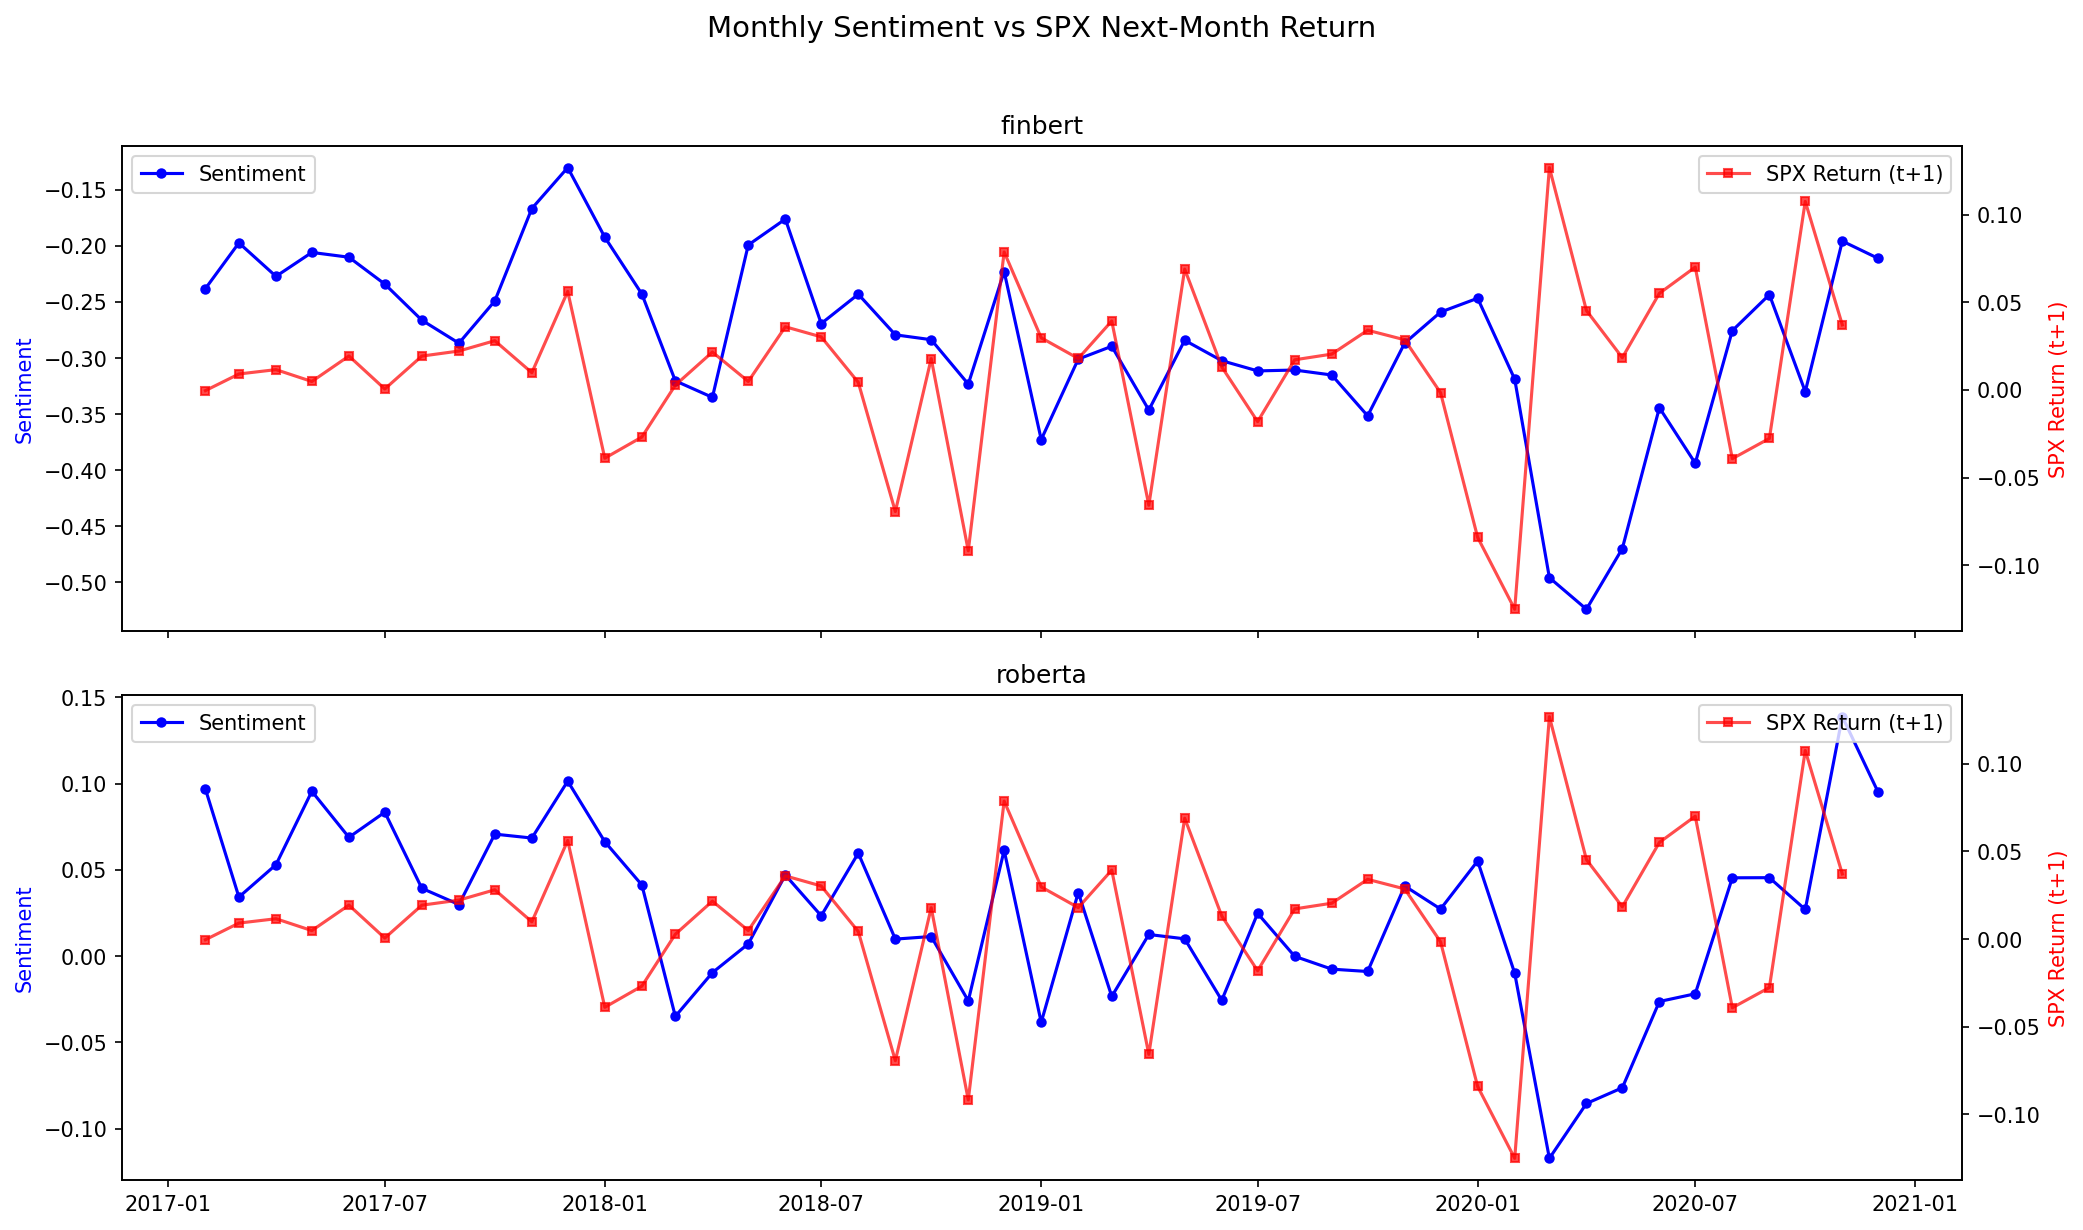

In [11]:
trend_df = pd.DataFrame(market_trend)
display(trend_df.round(4))

# Display saved scatter plots
from IPython.display import Image
import glob

scatter_files = sorted(glob.glob("../results/figures/scatter_*.png"))
for f in scatter_files:
    print(f"\n{Path(f).stem}")
    display(Image(filename=f, width=600))

# Time series overlay
overlay_path = "../results/figures/time_series_overlay.png"
if Path(overlay_path).exists():
    display(Image(filename=overlay_path, width=900))